In [2]:
from datascience import * 
import numpy as np
import matplotlib.pyplot as plots
path_data = '../../data/data8/'
%matplotlib inline
plots.style.use('fivethirtyeight')


## Assessing a Model

In data science, a model is a set of assumptions about data. Often, models include assumptions about chance processes used to generate data.

Sometimes, data scientists have to decide whether or not a model is good. In this section we will discuss an example of making such a decision.


## Jury model
In this model, we assess the jury selection concerning Robert Swain who complained that his jury had too few blacks on it compared to the population of blacks. There were 8 black men on a jury panel of 100 (8%) whereas the population of blacks was 26%.

To evaluate this model, if the values of the statistic are small then Mr. Swain's position is supported, otherwise the panel was drawn at random from the eligible population (the null hypothesis).

In [3]:
# This is to say that the percentage of blacks 
# in the population is 26%.
sample_size = 100
eligible_population = [0.26, 0.74]

In [8]:
sample_proportions(sample_size, eligible_population).item(0)

0.27

Let's get the counts instead of just the proportions.

`proportion` * `total`

In [9]:
def one_simulated_count():
    return sample_size * sample_proportions(
        sample_size, eligible_population).item(0)

### Simulating multiple values of the statistic
We want to see the variability in the counts. We'll generate 10000 simulated values of the count and see how they vary.

Toolkit: an array and a `for` loop.

In [10]:
counts = make_array()
repetitions = 10_000
for i in np.arange(repetitions):
    counts = np.append(counts, one_simulated_count())

### The Prediction under the model of random selection

To interpret the results of our simulation, we visualise the results in an _empirical histogram_ of the simulated counts.


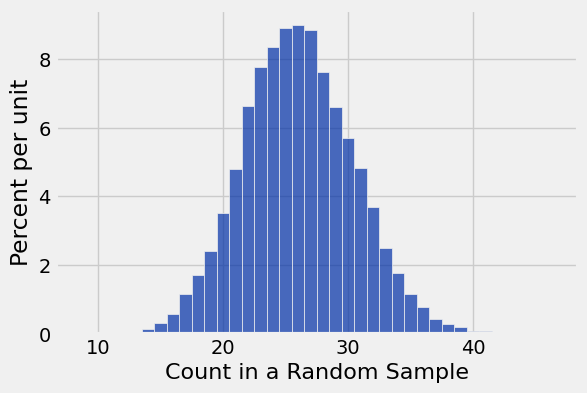

In [14]:
Table().with_column(
    "Count in a Random Sample", counts
).hist(bins=np.arange(8.5, 46.6, 1))



In [13]:
min(counts),  max(counts)

(11.0, 45.0)

From the histogram above we see that the range of Black jury panelists ranged from 11 to 45, with many centered between 25 and 27.

## Comparing the Prediction and the Data

With a point on the value 8, we can compare the predictions in the empirical histogram which actually present the effects of random selection in 10_000 draws.


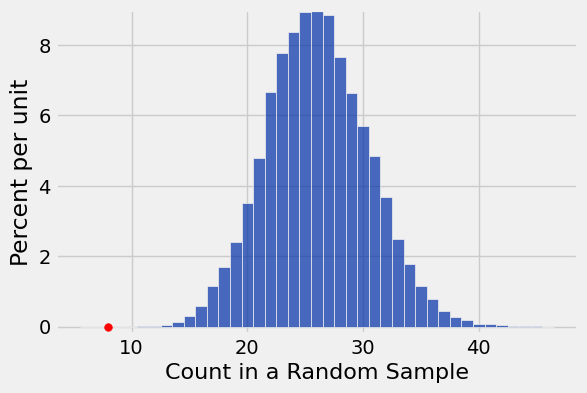

In [15]:
Table().with_column(
    'Count in a Random Sample', counts
).hist(bins = np.arange(5.5, 46.6, 1))
plots.ylim(-0.002, 0.09)
plots.scatter(8, 0, color='red', s=30);

This shows that the selection of 8 black panelists could not have been due to random selection. If they were selected at random, it could not have been as low as 8.

That implies that there was bias in the selection process. We can quantify this bias because the error is systematically in one direction.

## Multiple Categories

Whether jury panels are representative of the eligible population continues to be an important question. 

The general process of assessment will be the same as before. But this time we will consider panelists in multiple racial and ethnic categories, not just two. From a technical perspective, this will mean that we have to come up with a new statistic to simulate. Once we have simulated it and arrived at a conclusion, we will examine some of the underlying causes of the discrepancies that we observe.

### Jury selection in Alameda county

The focus of the study by the ACLU of Northern California was the racial and ethnic composition of jury panels in Alameda County. The ACLU compiled data on the composition of the jury panels in 11 felony trials in Alameda County in the years 2009 and 2010.

In those panels, the total number of people who reported for jury service was 1453. The ACLU gathered demographic data on all of these prosepctive jurors, and compared those data with the composition of all eligible jurors in the county.

The data are tabulated below in a table called jury. In each category, the first numerical value is the proportion of all eligible juror candidates in that category. The second value is the proportion of people in that category among those who appeared for the process of selection into the jury.

In [16]:
jury = Table().with_columns(
    'Ethnicity', make_array('Asian/PI', 'Black/AA', 'Caucasian', 'Hispanic', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.54, 0.12, 0.01),
    'Panels', make_array(0.26, 0.08, 0.54, 0.08, 0.04)
)

jury

Ethnicity,Eligible,Panels
Asian/PI,0.15,0.26
Black/AA,0.18,0.08
Caucasian,0.54,0.54
Hispanic,0.12,0.08
Other,0.01,0.04


From here we see the the Asian and Pacific Islanders are overrepresented while the Black and Hispanics are underrepresented.


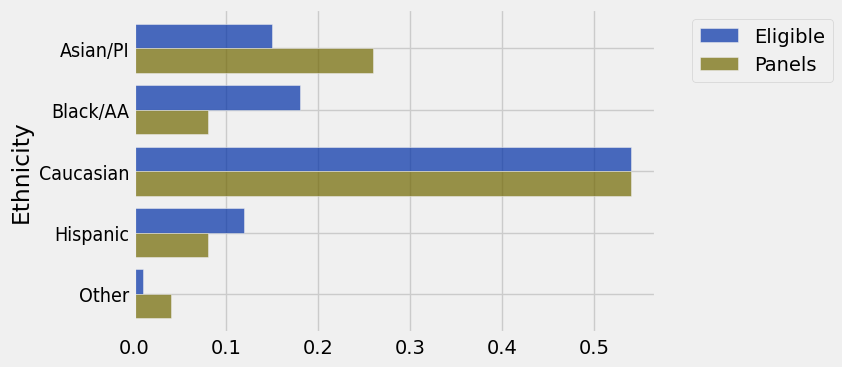

In [17]:
jury.barh("Ethnicity")


### Comparison with panels selected at random

What if we select a random sample of 1,453 people from the population of eligible jurors? Will the distribution of their ethnicities look like the distribution of the panels above?

Technical note. Random samples of prospective jurors would be selected without replacement. However, when the size of a sample is small relative to the size of the population, sampling without replacement resembles sampling with replacement; the proportions in the population don’t change much between draws.

The population of eligible jurors in Alameda County is over a million, and compared to that, a sample size of about 1500 is quite small. We will therefore sample with replacement.

In [18]:
eligible_population = jury.column('Eligible')
sample_distribution = sample_proportions(1453, eligible_population)
panels_and_sample = jury.with_column('Random Sample', sample_distribution)
panels_and_sample

Ethnicity,Eligible,Panels,Random Sample
Asian/PI,0.15,0.26,0.144529
Black/AA,0.18,0.08,0.170681
Caucasian,0.54,0.54,0.529938
Hispanic,0.12,0.08,0.143152
Other,0.01,0.04,0.0116999


In [19]:
sample_proportions?

Signature: sample_proportions(sample_size: int, probabilities)
Docstring:
Return the proportion of random draws for each outcome in a distribution.

This function is similar to np.random.Generator.multinomial, but returns proportions
instead of counts.

Args:
    ``sample_size``: The size of the sample to draw from the distribution.

    ``probabilities``: An array of probabilities that forms a distribution.

Returns:
    An array with the same length as ``probability`` that sums to 1.
File:      ~/Projects/Python/learning/.venv/lib/python3.12/site-packages/datascience/util.py
Type:      function

In [20]:
sample_distribution * 1453

array([ 210.,  248.,  770.,  208.,   17.])

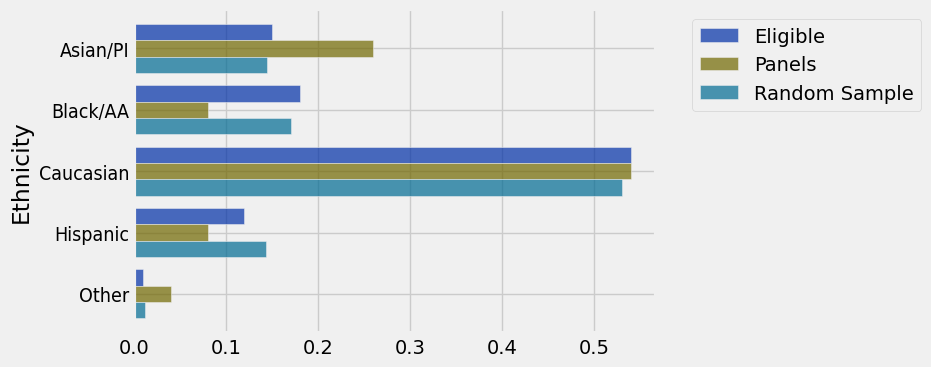

In [22]:
panels_and_sample.barh("Ethnicity")

The bar chart shows that the distribution of the random sample resembles the eligible population but the distribution of the panels does not.

To assess whether this observation is particular to one random sample or more general, we can simulate multiple panels under the model of random selection and see what the simulations predict. 

But we won’t be able to look at thousands of bar charts like the one above. We need a statistic that will help us assess whether or not the model or random selection is supported by the data.

## A New Statistic: The Distance between Two Distributions

To obtain this, we compute the _total variation distance_ between two distributions by finding the difference between the two proportions in each category.

In [23]:
# Augment the table with a column of differences between proportions

jury_with_diffs = jury.with_column(
    'Difference', jury.column('Panels') - jury.column('Eligible')
)
jury_with_diffs

Ethnicity,Eligible,Panels,Difference
Asian/PI,0.15,0.26,0.11
Black/AA,0.18,0.08,-0.1
Caucasian,0.54,0.54,0
Hispanic,0.12,0.08,-0.04
Other,0.01,0.04,0.03


In [24]:
# To avoid the cancelling out wie drop the negative signs
jury_with_diffs = jury_with_diffs.with_column(
    'Absolute Difference', np.abs(jury_with_diffs.column('Difference'))
)

jury_with_diffs

Ethnicity,Eligible,Panels,Difference,Absolute Difference
Asian/PI,0.15,0.26,0.11,0.11
Black/AA,0.18,0.08,-0.1,0.1
Caucasian,0.54,0.54,0,0
Hispanic,0.12,0.08,-0.04,0.04
Other,0.01,0.04,0.03,0.03


In [25]:
# The sum of the absolute difference is now double the positive entries. To 
# correct this we divide the sum by 2.

jury_with_diffs.column("Absolute Difference").sum() /2

0.14000000000000001

This quantity 0.14 is the total variation distance (TVD) between the distribution of ethnicities in the eligible population and the distribution in the panels.

The TVD measures how close the distributions are. The larger the TVD, the more different the two distributions are and the stronger the evidence against random selection.

## Simulating the Statistic under the Model

Let’s organize our calculation. Since we are going to be computing total variation distance repeatedly, we will first write a function that computes it for two given distributions.

The function total_variation_distance takes two arrays containing the distributions to compare, and returns the TVD between them.

In [26]:
def total_variation_distance(distribution_1, distribution_2):
    return sum(np.abs(distribution_1 - distribution_2)) / 2

In [27]:
total_variation_distance(jury.column('Panels'), jury.column('Eligible'))

0.14000000000000001

In [29]:
# calculating the TVD for random samples from the eligible pop
sample_distribution = sample_proportions(1453, eligible_population)
total_variation_distance(sample_distribution, eligible_population)

0.0079077770130763485

We see that this number is quite low, as it is taken from samples of the eligible population, compared to te 0.14. 

## Simulating one value of the Statistic

In [30]:
def one_simulated_tvd():
    sample_distribution = sample_proportions(1453, eligible_population)
    return total_variation_distance(sample_distribution, eligible_population)

## Simulating multiple values of the statistic

using a `for` loop and a storage array

In [31]:
tvds = make_array()
repetitions = 5000
for i in np.arange(repetitions):
    tvds = np.append(tvds, one_simulated_tvd())

In [33]:
len(tvds)

5000

## Assessing the Model of Random Selection

Here is the empirical histogram of the simulated distances. It shows that if you draw 1453 panelists at random from the pool of eligible candidates, then the distance between the distributions of the panelists and the eligible population is rarely more than about 0.05.

The panels in the study, however, were not quite so similar to the eligible population. The total variation distance between the panels and the population was 0.14, shown as the red dot on the horizontal axis.

It is far beyond the tail of the histogram and does not look at all like a typical distance between the distributions of a random sample and the eligible population.

In [34]:
min(tvds), max(tvds)

(0.0018031658637302078, 0.05357880247763247)

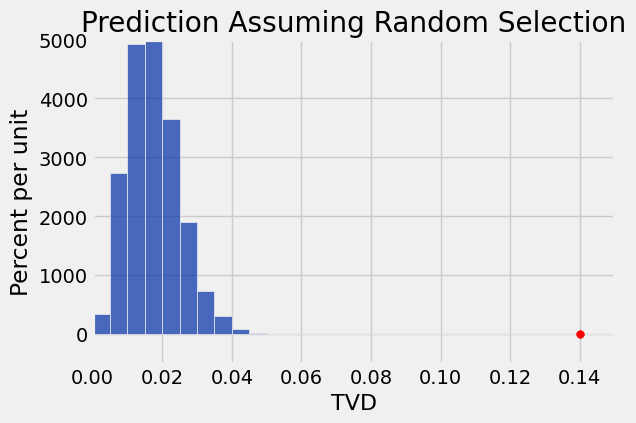

In [35]:
Table().with_column('TVD', tvds).hist(bins=np.arange(0, 0.2, 0.005))

# Plotting parameters; you can ignore this code
plots.title('Prediction Assuming Random Selection')
plots.xlim(0, 0.15)
plots.ylim(-5, 50)
plots.scatter(0.14, 0, color='red', s=30);

The simulation shows that the composition of the panels in the ACLU study is not consistent with the model of random selection. Our analysis supports the ACLU’s conclusion that the panels were not representative of the distribution provided for the eligible jurors.

## Reasons for the Bias

See here:
https://inferentialthinking.com/chapters/11/2/Multiple_Categories.html#reasons-for-the-bias